# Día 3 — Evaluación del Agente Completo (5h)

**Grupo 5 — Agente multi-paso (MedSAM + CNN + Gemini)**  
**Proyecto**: Clasificación de posicionamiento de dedo en escáner biométrico  
**Fecha**: Mayo 2026

---

## Objetivo del día

Ejecutar el agente sobre el set de test completo, comparar su precisión con la CNN sola, analizar los casos donde Gemini corrige o empeora, y ajustar el umbral de confianza según los resultados.

| Tarea | Descripción | Tiempo |
|-------|-------------|--------|
| Tarea 1 | Ejecutar el agente sobre el set de test y registrar % de intervención de Gemini | 1.5h |
| Tarea 2 | Comparar precisión del agente multi-paso vs CNN sola | 1.5h |
| Tarea 3 | Analizar casos donde Gemini corrige y donde empeora | 1h |
| Tarea 4 | Ajustar umbral de confianza según los resultados | 1h |

## 0. Imports y configuración

Mismos imports que el Día 2 + `sklearn` para métricas de clasificación.

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
from io import BytesIO
import base64
import os
import json
import random
from pathlib import Path
from dotenv import find_dotenv, load_dotenv
from openai import OpenAI
from segment_anything import sam_model_registry, SamPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, classification_report)
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

PyTorch : 2.11.0+cu130
CUDA    : False


### Configuración global

Mismos parámetros y rutas que el Día 2.

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Encontrar la raíz del proyecto buscando .git hacia arriba (funciona
# independientemente de desde dónde se lance Jupyter)
def _find_project_root():
    current = Path(os.getcwd()).resolve()
    for p in [current] + list(current.parents):
        if (p / ".git").exists():
            return p
    return current

PROJECT_ROOT = _find_project_root()
MEDSAM_CKPT  = PROJECT_ROOT / "MedSAM_GeminiAPI/Dia1/medsam_vit_b.pth"
CNN_CKPT     = PROJECT_ROOT / "CNN_desde_0/modelosEntrenados/best_ResidualCNN.pth"
DATASET_DIR  = PROJECT_ROOT / "CNN_desde_0/imagenes_procesadas"
GEMINI_MODEL = "google/gemini-2.0-flash-lite-001"

UMBRAL_CNN    = 0.70   # Día 1: p_cnn < 0.70 → Gemini arbitra
UMBRAL_MEDSAM = 0.60   # Día 1: score < 0.60 → error, imagen no válida

IDX_TO_LABEL = {0: "no", 1: "si"}   # igual que en CNN_Main_Final.ipynb

CNN_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print("\nVerificando rutas...")
for nombre, ruta in [("MedSAM checkpoint", MEDSAM_CKPT),
                     ("ResidualCNN pesos",  CNN_CKPT),
                     ("Dataset",            DATASET_DIR)]:
    ok = "✓" if ruta.exists() else "✗  FALTA"
    print(f"  {ok}  {nombre}: {ruta}")

print(f"\nDevice        : {DEVICE}")
print(f"Umbral CNN    : {UMBRAL_CNN}")
print(f"Umbral MedSAM : {UMBRAL_MEDSAM}")

Raíz del proyecto: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA

Verificando rutas...
  ✓  MedSAM checkpoint: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/MedSAM_GeminiAPI/Dia1/medsam_vit_b.pth
  ✓  ResidualCNN pesos: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/CNN_desde_0/modelosEntrenados/best_ResidualCNN.pth
  ✓  Dataset: /home/carlos/Escritorio/Carlos/Prog/Programacio/ProyectoFinal_CSEBDIA/CNN_desde_0/imagenes_procesadas

Device        : cpu
Umbral CNN    : 0.7
Umbral MedSAM : 0.6


### Cargar MedSAM

Carga robusta del checkpoint ViT-B.

In [3]:
raw = torch.load(MEDSAM_CKPT, map_location=DEVICE)
sam = sam_model_registry["vit_b"](checkpoint=None)
state = raw.get("model", raw) if isinstance(raw, dict) else raw
if isinstance(state, dict):
    missing, unexpected = sam.load_state_dict(state, strict=False)
    if missing:
        print(f"  Claves faltantes: {len(missing)}")

sam.to(DEVICE).eval()
predictor = SamPredictor(sam)
n_params = sum(p.numel() for p in sam.parameters())
print(f"✓ MedSAM (ViT-B) cargado — {n_params/1e6:.1f}M parámetros — device: {DEVICE}")

✓ MedSAM (ViT-B) cargado — 93.7M parámetros — device: cpu


### Cargar ResidualCNN

Arquitectura idéntica al Día 2 y al entrenamiento original del Grupo 2.

In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1      = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1        = nn.BatchNorm2d(out_channels)
        self.relu       = nn.ReLU(inplace=True)
        self.conv2      = nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False)
        self.bn2        = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        return self.relu(out + identity)


class ResidualCNN(nn.Module):
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()
        self.conv1  = nn.Sequential(
            nn.Conv2d(in_channels, 32, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.layer1 = self._make_layer(32,  64,  2)
        self.layer2 = self._make_layer(64,  128, 2, stride=2)
        self.layer3 = self._make_layer(128, 256, 2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

    def _make_layer(self, in_ch, out_ch, blocks, stride=1):
        down = None
        if stride != 1 or in_ch != out_ch:
            down = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )
        layers = [ResidualBlock(in_ch, out_ch, stride, down)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_ch, out_ch))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.avgpool(x)
        return self.fc(x)


model_cnn = ResidualCNN(in_channels=3, num_classes=2).to(DEVICE)
model_cnn.load_state_dict(torch.load(CNN_CKPT, map_location=DEVICE))
model_cnn.eval()
n = sum(p.numel() for p in model_cnn.parameters())
print(f"✓ ResidualCNN cargada — {n:,} parámetros — device: {DEVICE}")

✓ ResidualCNN cargada — 2,795,170 parámetros — device: cpu


### Configurar cliente Gemini (OpenRouter)

API key cargada del `.env`. Verificación de conexión antes de continuar.

In [5]:
load_dotenv(find_dotenv())
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if not OPENROUTER_API_KEY:
    raise ValueError("No se encontró OPENROUTER_API_KEY en el .env")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

# Verificación rápida
resp = client.chat.completions.create(
    model=GEMINI_MODEL,
    messages=[{"role": "user", "content": "Responde solo 'OK'."}]
)
print(f"✓ Gemini conectado: {resp.choices[0].message.content.strip()}")

✓ Gemini conectado: OK


### Clase `AgenteMedico`

Mismo código que el Día 2 — se copia aquí para que el notebook sea autónomo.

In [6]:
class AgenteMedico:
    """
    Agente multi-paso MedSAM → ResidualCNN → Gemini.
    Diseño del Día 1, implementación del Día 2 — Grupo 5, Proyecto IA RX.
    """
    UMBRAL_CNN    = UMBRAL_CNN
    UMBRAL_MEDSAM = UMBRAL_MEDSAM

    def __init__(self, predictor, cnn, gemini_client, device="cpu"):
        self.predictor = predictor
        self.cnn       = cnn
        self.client    = gemini_client
        self.device    = device

    # ── Paso 1: MedSAM ────────────────────────────────────────────────────────
    def segmentar(self, img_array):
        """
        Segmenta el dedo con MedSAM usando bounding box central (margen 10%).
        Condición de paso: score >= UMBRAL_MEDSAM (0.60).
        Devuelve (mask_bool_array, score_float).
        """
        h, w = img_array.shape[:2]
        m    = 0.10
        bbox = np.array([[int(w*m), int(h*m), int(w*(1-m)), int(h*(1-m))]])
        self.predictor.set_image(img_array)
        masks, scores, _ = self.predictor.predict(box=bbox, multimask_output=True)
        idx   = int(np.argmax(scores))
        score = float(scores[idx])
        if score < self.UMBRAL_MEDSAM:
            raise ValueError(
                f"Segmentación insuficiente: score={score:.3f} < {self.UMBRAL_MEDSAM}"
            )
        return masks[idx], score

    # ── Paso 2: ResidualCNN ───────────────────────────────────────────────────
    def clasificar(self, img_array, mask):
        """
        Aplica la máscara MedSAM y clasifica con ResidualCNN.
        Condición de paso: p_cnn >= UMBRAL_CNN (0.70) → veredicto directo.
        Devuelve (clase_str, p_max) — clase_str es 'SI' o 'NO'.
        """
        img_masked = img_array.copy()
        img_masked[~mask] = 0                        # fuera de máscara → negro

        tensor = CNN_TRANSFORM(
            Image.fromarray(img_masked.astype(np.uint8))
        ).unsqueeze(0).to(self.device)

        with torch.no_grad():
            probs = torch.softmax(self.cnn(tensor), dim=1).squeeze().cpu().numpy()

        idx_pred = int(np.argmax(probs))
        clase    = IDX_TO_LABEL[idx_pred].upper()    # 'SI' o 'NO'
        return clase, float(probs[idx_pred])

    # ── Control: ¿necesita árbitro? ───────────────────────────────────────────
    def necesita_arbitraje(self, p_cnn):
        """
        True si la CNN es incierta (p_cnn < UMBRAL_CNN).
        False → veredicto directo de la CNN.
        """
        return p_cnn < self.UMBRAL_CNN

    # ── Paso 3: Gemini (condicional) ─────────────────────────────────────────
    def consultar_gemini(self, img_array, mask, pred_cnn, p_cnn):
        """
        Consulta a Gemini como árbitro multimodal.
        Recibe: imagen original + overlay MedSAM + predicción CNN + confianza.
        Devuelve: (clase_final_str, razon_str).
        """
        def _to_b64(arr):
            buf = BytesIO()
            pil = Image.fromarray(arr.astype(np.uint8))
            if pil.mode != "RGB":
                pil = pil.convert("RGB")
            pil.save(buf, format="JPEG", quality=85)
            return base64.b64encode(buf.getvalue()).decode()

        overlay         = img_array.copy()
        overlay[mask]   = [50, 220, 80]              # máscara en verde

        prompt = (
            "Eres un sistema experto en análisis de posicionamiento biométrico.\n"
            "Se te presentan dos imágenes de una radiografía térmica de un dedo sobre un escáner biométrico.\n\n"
            "IMAGEN 1: Fotografía original del dedo sobre el escáner.\n"
            "IMAGEN 2: Máscara de segmentación de MedSAM (región del dedo resaltada en verde).\n\n"
            f"El clasificador CNN predijo: [{pred_cnn}] con confianza [{p_cnn:.1%}].\n"
            "Esta confianza es BAJA (< 70%), necesitamos tu criterio.\n\n"
            "El escáner tiene una franja luminosa (zona brillante). El dedo entero debe quedar centrado\n"
            "encima de esa franja, sin desplazarse ni salirse. Ese es el único criterio.\n\n"
            "CORRECTO (SI):\n"
            "- El dedo está colocado encima de la franja luminosa y centrado en ella.\n"
            "- El dedo no se sale de la franja ni por los lados ni por arriba/abajo.\n"
            "- El dedo cubre la franja de forma plana, sin estar girado ni inclinado.\n\n"
            "INCORRECTO (NO):\n"
            "- El dedo está desplazado: parte del dedo queda fuera de la franja luminosa.\n"
            "- El dedo solo toca un extremo o un lado de la franja, no el centro.\n"
            "- El dedo está girado o inclinado de modo que no cubre bien la franja.\n\n"
            "Responde ÚNICAMENTE con este formato exacto:\n"
            "VEREDICTO: [SI / NO]\n"
            "RAZÓN: [Una sola frase con el criterio visual determinante]"
        )

        resp = self.client.chat.completions.create(
            model=GEMINI_MODEL,
            messages=[{"role": "user", "content": [
                {"type": "image_url",
                 "image_url": {"url": f"data:image/jpeg;base64,{_to_b64(img_array)}"}},
                {"type": "image_url",
                 "image_url": {"url": f"data:image/jpeg;base64,{_to_b64(overlay)}"}},
                {"type": "text", "text": prompt}
            ]}],
            temperature=0.1,
            max_tokens=200
        )

        raw = resp.choices[0].message.content.strip()
        clase_final, razon = "NO", raw

        for line in raw.splitlines():
            upper = line.upper()
            if upper.startswith("VEREDICTO:"):
                clase_final = "SI" if "SI" in upper else "NO"
            elif upper.startswith("RAZ"):
                razon = line.split(":", 1)[-1].strip()

        return clase_final, razon

    # ── Orquestador: pipeline completo ────────────────────────────────────────
    def veredicto_final(self, ruta_imagen):
        """
        Ejecuta el pipeline completo MedSAM → CNN → (Gemini si necesario).

        Devuelve dict con trazabilidad completa:
          imagen, error, score_medsam, clase_cnn, p_cnn,
          arbitraje_gemini, clase_final, razon_gemini
        """
        res = {
            "imagen"         : Path(ruta_imagen).name,
            "error"          : None,
            "score_medsam"   : None,
            "clase_cnn"      : None,
            "p_cnn"          : None,
            "arbitraje_gemini": False,
            "clase_final"    : None,
            "razon_gemini"   : None,
        }
        try:
            img = np.array(Image.open(ruta_imagen).convert("RGB"))

            # Paso 1
            mask, score = self.segmentar(img)
            res["score_medsam"] = round(score, 4)

            # Paso 2
            clase_cnn, p_cnn = self.clasificar(img, mask)
            res["clase_cnn"], res["p_cnn"] = clase_cnn, round(p_cnn, 4)

            # Paso 3 (condicional)
            if self.necesita_arbitraje(p_cnn):
                res["arbitraje_gemini"] = True
                clase_final, razon      = self.consultar_gemini(img, mask, clase_cnn, p_cnn)
                res["clase_final"]      = clase_final
                res["razon_gemini"]     = razon
            else:
                res["clase_final"] = clase_cnn

        except ValueError as e:
            res["error"] = str(e)

        return res

### Instanciar el agente

In [7]:
agente = AgenteMedico(
    predictor     = predictor,
    cnn           = model_cnn,
    gemini_client = client,
    device        = str(DEVICE)
)
print("✓ AgenteMedico listo")
print(f"  Umbral CNN    : {agente.UMBRAL_CNN}")
print(f"  Umbral MedSAM : {agente.UMBRAL_MEDSAM}")

✓ AgenteMedico listo
  Umbral CNN    : 0.7
  Umbral MedSAM : 0.6


---

## Tarea 1 — Ejecución sobre el set de test completo *(1.5h)*

Se ejecuta `agente.veredicto_final()` sobre **todas las imágenes del set de test** (no solo los 10 casos del Día 2). Se registra en cada imagen:

- `score_medsam`: confianza de la segmentación
- `clase_cnn` + `p_cnn`: predicción y confianza de la CNN
- `arbitraje_gemini`: si intervino Gemini
- `clase_final`: veredicto definitivo
- `razon_gemini`: justificación textual (si Gemini intervino)

In [8]:
# Set de test completo
test_si  = sorted((DATASET_DIR / "test" / "si").glob("*.png"))
test_no  = sorted((DATASET_DIR / "test" / "no").glob("*.png"))
test_imgs = [(p, "SI") for p in test_si] + [(p, "NO") for p in test_no]

print(f"Set de test: {len(test_si)} SI + {len(test_no)} NO = {len(test_imgs)} imágenes")
print("Ejecutando el agente completo (MedSAM → CNN → Gemini)...\n")

resultados = []
for i, (img_path, clase_real) in enumerate(test_imgs):
    res = agente.veredicto_final(img_path)
    res["clase_real"] = clase_real

    if res["error"]:
        estado = f"✗ ERROR: {res['error']}"
    else:
        decide  = "[Gemini]" if res["arbitraje_gemini"] else "[CNN]   "
        acierto = "✓" if res["clase_final"] == clase_real else "✗"
        estado  = f"{decide} → {res['clase_final']} {acierto}"

    print(f"  [{i+1:2d}/{len(test_imgs)}] {img_path.name:28s} | real: {clase_real} | {estado}")
    resultados.append(res)

print(f"\n✓ Evaluación completada: {len(resultados)} imágenes procesadas")


Set de test: 8 SI + 9 NO = 17 imágenes
Ejecutando el agente completo (MedSAM → CNN → Gemini)...

  [ 1/17] img_1776863513281.png        | real: SI | ✗ ERROR: Segmentación insuficiente: score=0.596 < 0.6
  [ 2/17] img_1776863889130.png        | real: SI | [Gemini] → SI ✓
  [ 3/17] img_1776863909985.png        | real: SI | [Gemini] → SI ✓
  [ 4/17] img_1777026517084.png        | real: SI | [Gemini] → NO ✗
  [ 5/17] img_1777026555963.png        | real: SI | ✗ ERROR: Segmentación insuficiente: score=0.599 < 0.6
  [ 6/17] img_1777027170211.png        | real: SI | [Gemini] → SI ✓
  [ 7/17] img_1777027595858.png        | real: SI | ✗ ERROR: Segmentación insuficiente: score=0.587 < 0.6
  [ 8/17] img_1777028264615.png        | real: SI | [Gemini] → NO ✗
  [ 9/17] img_1776864630193.png        | real: NO | ✗ ERROR: Segmentación insuficiente: score=0.590 < 0.6
  [10/17] img_1776864644631.png        | real: NO | [Gemini] → SI ✗
  [11/17] img_1777026670875.png        | real: NO | [Gemini] → SI ✗
  [

### Estadísticas de intervención y distribución de scores

Imágenes válidas        : 10
Rechazadas (MedSAM<0.60): 7
CNN decide directamente : 0  (0.0%)
Gemini interviene       : 10  (100.0%)


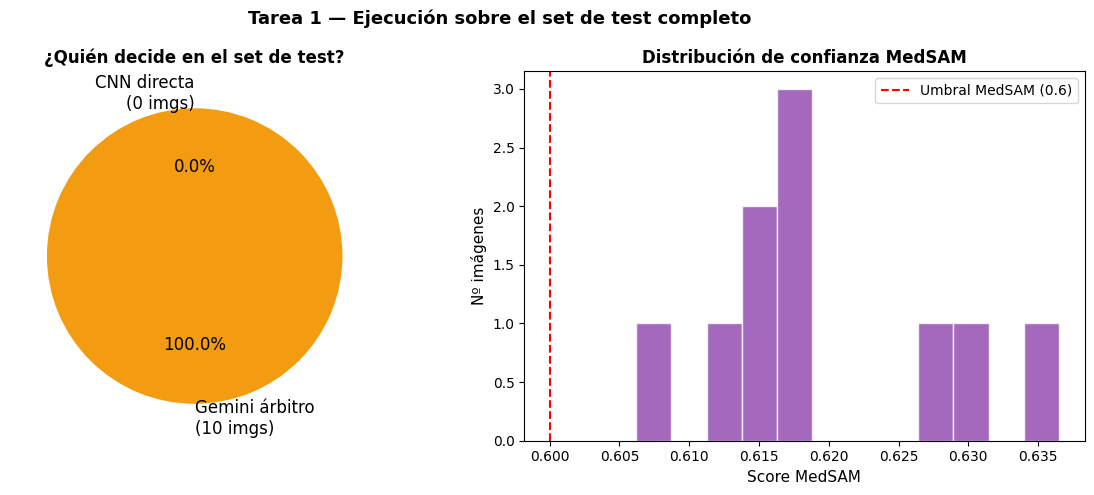

✓ dia3_intervencion_gemini.png guardada


In [9]:
validos = [r for r in resultados if not r["error"]]
errores = [r for r in resultados if r["error"]]

n_total  = len(validos)
n_gemini = sum(1 for r in validos if r["arbitraje_gemini"])
n_cnn    = n_total - n_gemini
pct_g    = 100 * n_gemini / n_total if n_total else 0

print(f"Imágenes válidas        : {n_total}")
print(f"Rechazadas (MedSAM<0.60): {len(errores)}")
print(f"CNN decide directamente : {n_cnn}  ({100 - pct_g:.1f}%)")
print(f"Gemini interviene       : {n_gemini}  ({pct_g:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Pie chart — quién decide
axes[0].pie(
    [n_cnn, n_gemini],
    labels=[f"CNN directa\n({n_cnn} imgs)", f"Gemini árbitro\n({n_gemini} imgs)"],
    colors=["#27ae60", "#f39c12"],
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 12},
)
axes[0].set_title("¿Quién decide en el set de test?", fontsize=12, fontweight="bold")

# Distribución de score MedSAM
scores = [r["score_medsam"] for r in validos]
axes[1].hist(scores, bins=12, color="#8e44ad", alpha=0.8, edgecolor="white")
axes[1].axvline(UMBRAL_MEDSAM, color="red", linestyle="--", linewidth=1.5, label=f"Umbral MedSAM ({UMBRAL_MEDSAM})")
axes[1].set_xlabel("Score MedSAM", fontsize=11)
axes[1].set_ylabel("Nº imágenes", fontsize=11)
axes[1].set_title("Distribución de confianza MedSAM", fontsize=12, fontweight="bold")
axes[1].legend()

plt.suptitle("Tarea 1 — Ejecución sobre el set de test completo", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("dia3_intervencion_gemini.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ dia3_intervencion_gemini.png guardada")


---

## Tarea 2 — Comparativa: CNN sola vs Agente completo *(1.5h)*

Se evalúa la CNN **directamente sobre la imagen original** (sin máscara MedSAM, sin Gemini) para usar como línea base, y se compara con el agente completo.

Métricas evaluadas: Accuracy, Precision, Recall, F1 por clase y Macro F1.

In [10]:
# CNN sola: sin máscara, sin Gemini — imagen original directa
print("Evaluando CNN sola sobre el set de test (sin máscara, sin Gemini)...")

cnn_sola = []
model_cnn.eval()
for img_path, clase_real in test_imgs:
    tensor = CNN_TRANSFORM(Image.open(img_path).convert("RGB")).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model_cnn(tensor), dim=1).squeeze().cpu().numpy()
    pred = IDX_TO_LABEL[int(np.argmax(probs))].upper()
    cnn_sola.append({
        "imagen": img_path.name, "clase_real": clase_real,
        "pred": pred, "p_cnn": float(probs.max()),
    })
    acierto = "✓" if pred == clase_real else "✗"
    print(f"  {img_path.name:28s} | real: {clase_real} | CNN: {pred} ({probs.max():.2f}) {acierto}")

acc_cnn = accuracy_score([r["clase_real"] for r in cnn_sola], [r["pred"] for r in cnn_sola])
print(f"\nCNN sola — Accuracy: {acc_cnn:.1%}")


Evaluando CNN sola sobre el set de test (sin máscara, sin Gemini)...
  img_1776863513281.png        | real: SI | CNN: SI (0.55) ✓
  img_1776863889130.png        | real: SI | CNN: SI (0.51) ✓
  img_1776863909985.png        | real: SI | CNN: SI (0.52) ✓
  img_1777026517084.png        | real: SI | CNN: SI (0.50) ✓
  img_1777026555963.png        | real: SI | CNN: NO (0.54) ✗
  img_1777027170211.png        | real: SI | CNN: NO (0.51) ✗
  img_1777027595858.png        | real: SI | CNN: NO (0.53) ✗
  img_1777028264615.png        | real: SI | CNN: NO (0.50) ✗
  img_1776864630193.png        | real: NO | CNN: SI (0.81) ✗
  img_1776864644631.png        | real: NO | CNN: SI (0.56) ✗
  img_1777026670875.png        | real: NO | CNN: NO (0.52) ✓
  img_1777027201011.png        | real: NO | CNN: NO (0.54) ✓
  img_1777027661410.png        | real: NO | CNN: NO (0.54) ✓
  img_1777027673930.png        | real: NO | CNN: NO (0.53) ✓
  img_1777028297087.png        | real: NO | CNN: NO (0.51) ✓
  img_1777028325

### Métricas detalladas y matrices de confusión


========== CNN sola ==========
  Accuracy       : 60.0%
  Precision (SI) : 60.0%
  Recall    (SI) : 60.0%
  F1        (SI) : 60.0%
  F1        (NO) : 60.0%
  Macro F1       : 60.0%

========== Agente completo ==========
  Accuracy       : 40.0%
  Precision (SI) : 42.9%
  Recall    (SI) : 60.0%
  F1        (SI) : 50.0%
  F1        (NO) : 25.0%
  Macro F1       : 37.5%


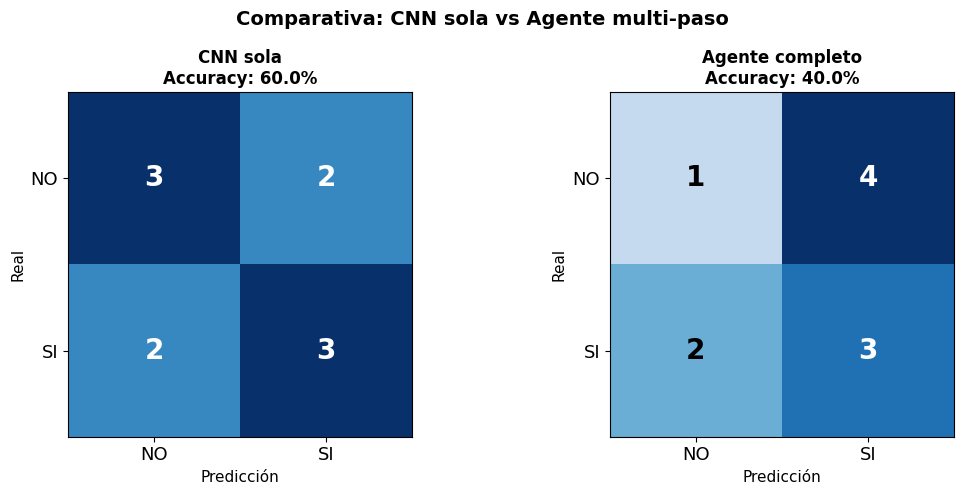

✓ dia3_comparativa_confusion.png guardada


In [11]:
# Alinear imágenes válidas (excluir las que falló MedSAM)
nombres_validos = {r["imagen"] for r in validos}
cnn_f = [r for r in cnn_sola if r["imagen"] in nombres_validos]

y_true_cnn = [r["clase_real"] for r in cnn_f]
y_pred_cnn = [r["pred"] for r in cnn_f]

y_true_ag  = [r["clase_real"]  for r in validos]
y_pred_ag  = [r["clase_final"] for r in validos]

def metricas(yt, yp, nombre):
    acc   = accuracy_score(yt, yp)
    p_si  = precision_score(yt, yp, pos_label="SI", zero_division=0)
    r_si  = recall_score(yt, yp, pos_label="SI", zero_division=0)
    f1_si = f1_score(yt, yp, pos_label="SI", zero_division=0)
    f1_no = f1_score(yt, yp, pos_label="NO", zero_division=0)
    mf1   = f1_score(yt, yp, average="macro", zero_division=0)
    print(f"\n{'='*10} {nombre} {'='*10}")
    print(f"  Accuracy       : {acc:.1%}")
    print(f"  Precision (SI) : {p_si:.1%}")
    print(f"  Recall    (SI) : {r_si:.1%}")
    print(f"  F1        (SI) : {f1_si:.1%}")
    print(f"  F1        (NO) : {f1_no:.1%}")
    print(f"  Macro F1       : {mf1:.1%}")
    return dict(acc=acc, p_si=p_si, r_si=r_si, f1_si=f1_si, f1_no=f1_no, mf1=mf1)

m_cnn = metricas(y_true_cnn, y_pred_cnn, "CNN sola")
m_ag  = metricas(y_true_ag,  y_pred_ag,  "Agente completo")

# ── Matrices de confusión lado a lado ────────────────────────────────────────
labels = ["NO", "SI"]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, (yt, yp, titulo, acc) in zip(axes, [
        (y_true_cnn, y_pred_cnn, "CNN sola",       m_cnn["acc"]),
        (y_true_ag,  y_pred_ag,  "Agente completo", m_ag["acc"]),
]):
    cm = confusion_matrix(yt, yp, labels=labels)
    ax.imshow(cm, cmap="Blues", vmin=0)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(labels, fontsize=13)
    ax.set_yticklabels(labels, fontsize=13)
    ax.set_xlabel("Predicción", fontsize=11)
    ax.set_ylabel("Real",       fontsize=11)
    ax.set_title(f"{titulo}\nAccuracy: {acc:.1%}", fontsize=12, fontweight="bold")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    fontsize=20, fontweight="bold",
                    color="white" if cm[i, j] > cm.max() / 2 else "black")

plt.suptitle("Comparativa: CNN sola vs Agente multi-paso", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("dia3_comparativa_confusion.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ dia3_comparativa_confusion.png guardada")


### Gráfico comparativo de métricas

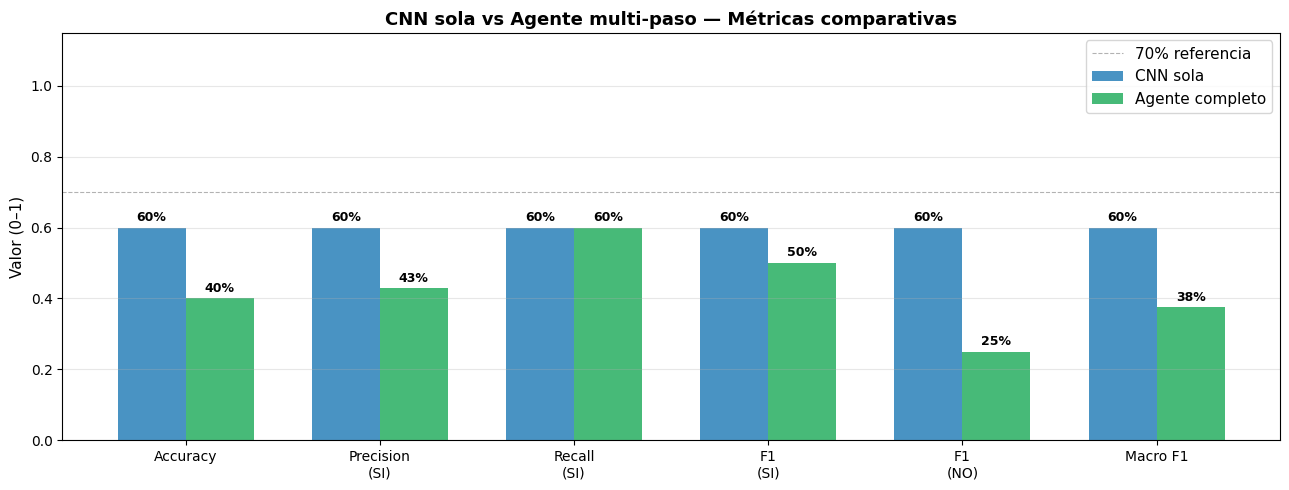

✓ dia3_comparativa_metricas.png guardada


In [12]:
etiquetas = ["Accuracy", "Precision\n(SI)", "Recall\n(SI)", "F1\n(SI)", "F1\n(NO)", "Macro F1"]
vals_cnn = [m_cnn["acc"], m_cnn["p_si"], m_cnn["r_si"], m_cnn["f1_si"], m_cnn["f1_no"], m_cnn["mf1"]]
vals_ag  = [m_ag["acc"],  m_ag["p_si"],  m_ag["r_si"],  m_ag["f1_si"],  m_ag["f1_no"],  m_ag["mf1"]]

x = np.arange(len(etiquetas))
w = 0.35
fig, ax = plt.subplots(figsize=(13, 5))
b1 = ax.bar(x - w/2, vals_cnn, w, label="CNN sola",        color="#2980b9", alpha=0.85)
b2 = ax.bar(x + w/2, vals_ag,  w, label="Agente completo", color="#27ae60", alpha=0.85)

for bar in list(b1) + list(b2):
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f"{h:.0%}",
            ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.axhline(0.70, color="gray", linestyle="--", linewidth=0.8, alpha=0.6, label="70% referencia")
ax.set_xticks(x); ax.set_xticklabels(etiquetas, fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Valor (0–1)", fontsize=11)
ax.set_title("CNN sola vs Agente multi-paso — Métricas comparativas", fontsize=13, fontweight="bold")
ax.legend(fontsize=11); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("dia3_comparativa_metricas.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ dia3_comparativa_metricas.png guardada")


---

## Tarea 3 — Análisis de las intervenciones de Gemini *(1h)*

Se clasifican **todas las imágenes donde Gemini intervino** en cuatro categorías:

| Categoría | Descripción |
|-----------|-------------|
| **Gemini corrige** | La CNN se equivocó, Gemini acierta ✅ |
| **Gemini empeora** | La CNN acertaba, Gemini se equivoca ❌ |
| **Ambos correctos** | CNN y Gemini coinciden y aciertan 🟢 |
| **Ambos incorrectos** | CNN y Gemini coinciden y fallan 🔴 |

Total intervenciones Gemini : 10
  ✅ Gemini CORRIGE a CNN   :  1  (10%)
  ❌ Gemini EMPEORA a CNN   :  2  (20%)
  🟢 Ambos CORRECTOS        :  3  (30%)
  🔴 Ambos INCORRECTOS      :  4  (40%)


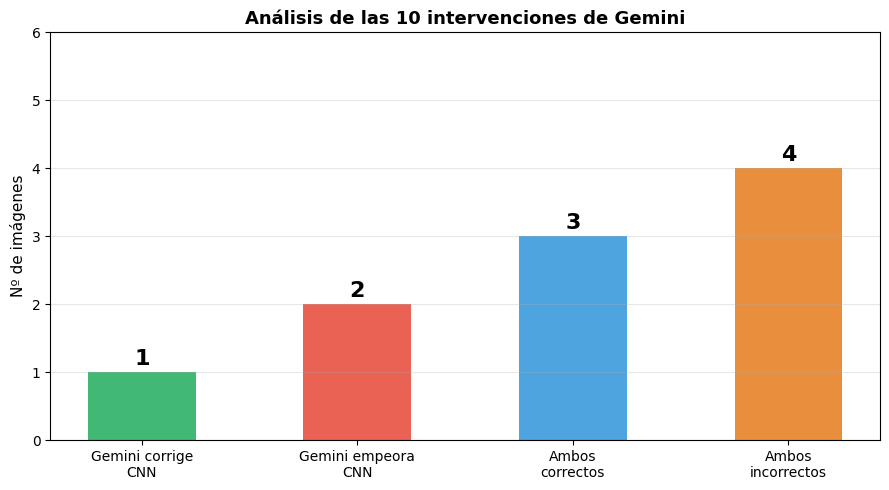

✓ dia3_analisis_gemini.png guardada

--- GEMINI CORRIGE a CNN ---
  img_1777028637517.png        | real: NO | CNN: SI (0.52) → Gemini: NO
    Razón: El dedo está desplazado y parte de él queda fuera de la franja luminosa.

--- GEMINI EMPEORA a CNN ---
  img_1777026517084.png        | real: SI | CNN: SI (0.51) → Gemini: NO
    Razón: El dedo está desplazado y parte de él queda fuera de la franja luminosa.
  img_1777028264615.png        | real: SI | CNN: SI (0.52) → Gemini: NO
    Razón: El dedo está desplazado y parte de él queda fuera de la franja luminosa.


In [13]:
# Filtrar solo intervenciones de Gemini
gemini_casos = [r for r in validos if r["arbitraje_gemini"]]

corrige    = []  # CNN mal, Gemini bien
empeora    = []  # CNN bien, Gemini mal
ambos_bien = []  # ambos aciertan
ambos_mal  = []  # ambos fallan

for r in gemini_casos:
    cnn_ok    = r["clase_cnn"]   == r["clase_real"]
    gemini_ok = r["clase_final"] == r["clase_real"]
    if   not cnn_ok and gemini_ok:  corrige.append(r)
    elif cnn_ok and not gemini_ok:  empeora.append(r)
    elif cnn_ok and gemini_ok:      ambos_bien.append(r)
    else:                           ambos_mal.append(r)

n_g = len(gemini_casos)
pct = lambda x: f"{100*len(x)/n_g:.0f}%" if n_g else "—"

print(f"Total intervenciones Gemini : {n_g}")
print(f"  ✅ Gemini CORRIGE a CNN   : {len(corrige):2d}  ({pct(corrige)})")
print(f"  ❌ Gemini EMPEORA a CNN   : {len(empeora):2d}  ({pct(empeora)})")
print(f"  🟢 Ambos CORRECTOS        : {len(ambos_bien):2d}  ({pct(ambos_bien)})")
print(f"  🔴 Ambos INCORRECTOS      : {len(ambos_mal):2d}  ({pct(ambos_mal)})")

# Gráfico de barras de categorías
cats   = ["Gemini corrige\nCNN", "Gemini empeora\nCNN", "Ambos\ncorrectos", "Ambos\nincorrectos"]
vals   = [len(corrige), len(empeora), len(ambos_bien), len(ambos_mal)]
colors = ["#27ae60", "#e74c3c", "#3498db", "#e67e22"]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cats, vals, color=colors, width=0.5, alpha=0.88)
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            str(v), ha="center", va="bottom", fontsize=16, fontweight="bold")
ax.set_ylabel("Nº de imágenes", fontsize=11)
ax.set_title(f"Análisis de las {n_g} intervenciones de Gemini", fontsize=13, fontweight="bold")
ax.set_ylim(0, max(vals) + 2 if vals else 3)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("dia3_analisis_gemini.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ dia3_analisis_gemini.png guardada")

# Imprimir razones de Gemini
for titulo, grupo in [
    ("GEMINI CORRIGE a CNN", corrige),
    ("GEMINI EMPEORA a CNN", empeora),
]:
    if grupo:
        print(f"\n--- {titulo} ---")
        for r in grupo:
            print(f"  {r['imagen']:28s} | real: {r['clase_real']} | "
                  f"CNN: {r['clase_cnn']} ({r['p_cnn']:.2f}) → Gemini: {r['clase_final']}")
            print(f"    Razón: {r['razon_gemini']}")


### Visualización de los casos de intervención

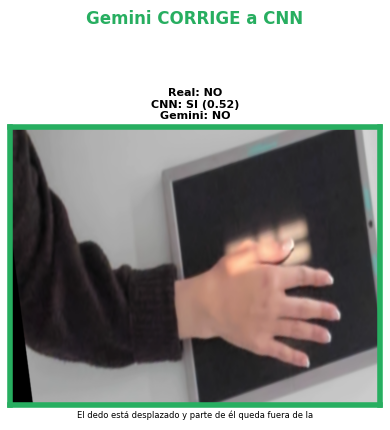

✓ dia3_gemini_corrige_a_cnn.png guardada


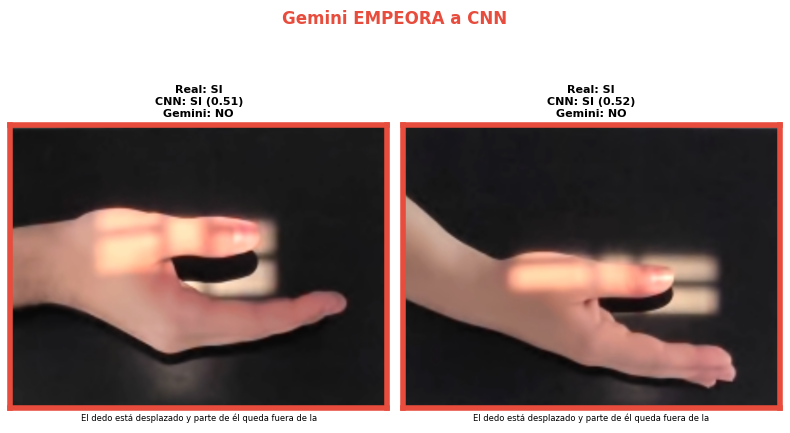

✓ dia3_gemini_empeora_a_cnn.png guardada


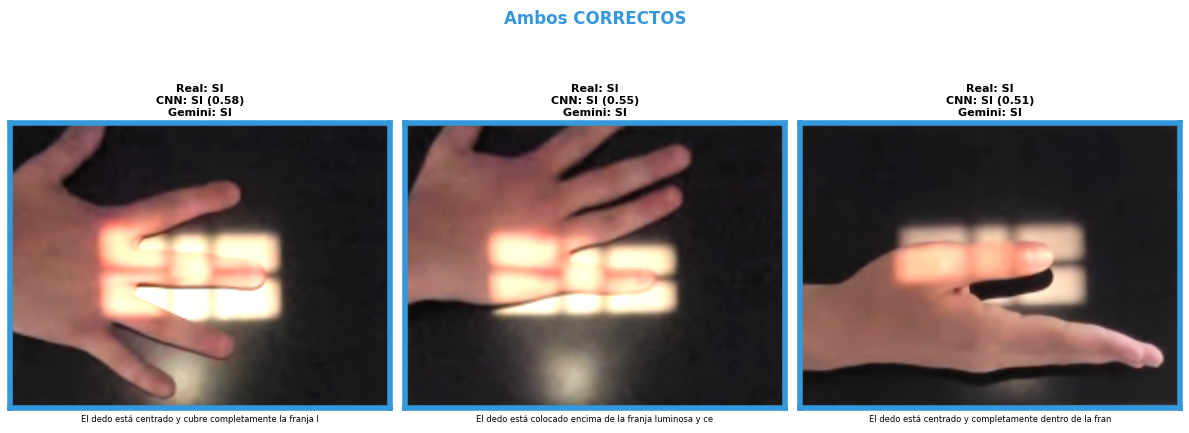

✓ dia3_ambos_correctos.png guardada


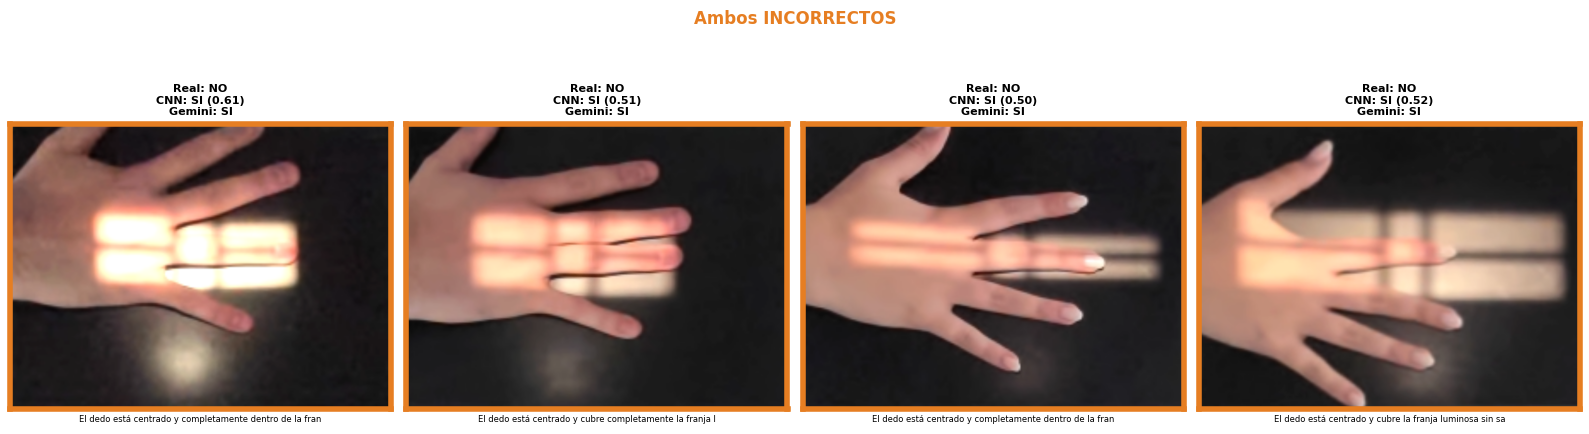

✓ dia3_ambos_incorrectos.png guardada


In [14]:
def _find_img(nombre):
    for split in ["train", "test"]:
        for clase in ["si", "no"]:
            p = DATASET_DIR / split / clase / nombre
            if p.exists():
                return p
    return None

def vis_casos(casos, titulo, color, max_show=5):
    if not casos:
        print(f"Sin casos: {titulo}")
        return
    n = min(len(casos), max_show)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, r in zip(axes, casos[:n]):
        img_path = _find_img(r["imagen"])
        if img_path:
            ax.imshow(np.array(Image.open(img_path).convert("RGB")))
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(4)
        ax.set_title(
            f"Real: {r['clase_real']}\n"
            f"CNN: {r['clase_cnn']} ({r['p_cnn']:.2f})\n"
            f"Gemini: {r['clase_final']}",
            fontsize=8, fontweight="bold",
        )
        razon = (r["razon_gemini"] or "")[:55]
        ax.set_xlabel(razon, fontsize=6)
        ax.set_xticks([]); ax.set_yticks([])
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(titulo, fontsize=12, fontweight="bold", color=color)
    plt.tight_layout()
    fname = "dia3_" + titulo.lower().replace(" ", "_")[:35] + ".png"
    plt.savefig(fname, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"✓ {fname} guardada")

vis_casos(corrige,    "Gemini CORRIGE a CNN",    "#27ae60")
vis_casos(empeora,    "Gemini EMPEORA a CNN",    "#e74c3c")
vis_casos(ambos_bien, "Ambos CORRECTOS",          "#3498db")
vis_casos(ambos_mal,  "Ambos INCORRECTOS",        "#e67e22")


---

## Tarea 4 — Ajuste del umbral de confianza *(1h)*

Se simula qué habría pasado con umbrales distintos al 0.70 original.

**Metodología**: ya tenemos `p_cnn` y la respuesta de Gemini para todos los casos donde `p_cnn < 0.70`. Para simular umbrales ≤ 0.70 la simulación es exacta. Para umbrales > 0.70, los casos nuevos (0.70 ≤ p_cnn < t) no tienen respuesta Gemini y se usa la CNN como fallback — por eso se marcan como *estimado*.

El gráfico muestra el trade-off entre calidad (accuracy/F1) y coste (% de llamadas a Gemini).

In [15]:
# Simulación de umbrales usando los datos ya recopilados.
# Para t <= 0.70: simulación exacta (tenemos respuesta Gemini para todos los p_cnn < 0.70).
# Para t > 0.70: los casos nuevos (0.70 <= p_cnn < t) no tienen respuesta Gemini → se usa CNN.

thresholds  = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
sim_results = []

for t in thresholds:
    preds, trues, n_g_t = [], [], 0
    for r in validos:
        p = r["p_cnn"]
        if p >= t:
            pred = r["clase_cnn"]     # CNN decide
        elif r["arbitraje_gemini"]:   # p < t y Gemini fue llamado (p < 0.70 original)
            pred = r["clase_final"]
            n_g_t += 1
        else:                         # p < t pero p >= 0.70 → sin Gemini → usamos CNN
            pred = r["clase_cnn"]
        preds.append(pred)
        trues.append(r["clase_real"])

    acc  = accuracy_score(trues, preds)
    mf1  = f1_score(trues, preds, average="macro", zero_division=0)
    f1si = f1_score(trues, preds, pos_label="SI", zero_division=0)
    sim_results.append(dict(
        t=t, acc=acc, mf1=mf1, f1si=f1si,
        n_g=n_g_t, pct_g=100*n_g_t/len(validos),
        exacto=(t <= UMBRAL_CNN),
    ))

print(f"{'Umbral':>7} {'Accuracy':>10} {'Macro F1':>10} {'F1 SI':>8} {'%Gemini':>10}  Nota")
print("-" * 62)
for s in sim_results:
    nota = "simulación exacta" if s["exacto"] else "estimado (sin Gemini para casos nuevos)"
    print(f"  {s['t']:.2f}  {s['acc']:>10.1%} {s['mf1']:>10.1%} {s['f1si']:>8.1%} "
          f"{s['pct_g']:>9.1f}%  {nota}")


 Umbral   Accuracy   Macro F1    F1 SI    %Gemini  Nota
--------------------------------------------------------------
  0.50       50.0%      33.3%    66.7%       0.0%  simulación exacta
  0.55       40.0%      37.5%    50.0%      70.0%  simulación exacta
  0.60       40.0%      37.5%    50.0%      90.0%  simulación exacta
  0.65       40.0%      37.5%    50.0%     100.0%  simulación exacta
  0.70       40.0%      37.5%    50.0%     100.0%  simulación exacta
  0.75       40.0%      37.5%    50.0%     100.0%  estimado (sin Gemini para casos nuevos)
  0.80       40.0%      37.5%    50.0%     100.0%  estimado (sin Gemini para casos nuevos)
  0.85       40.0%      37.5%    50.0%     100.0%  estimado (sin Gemini para casos nuevos)
  0.90       40.0%      37.5%    50.0%     100.0%  estimado (sin Gemini para casos nuevos)


### Gráfico de sensibilidad del umbral

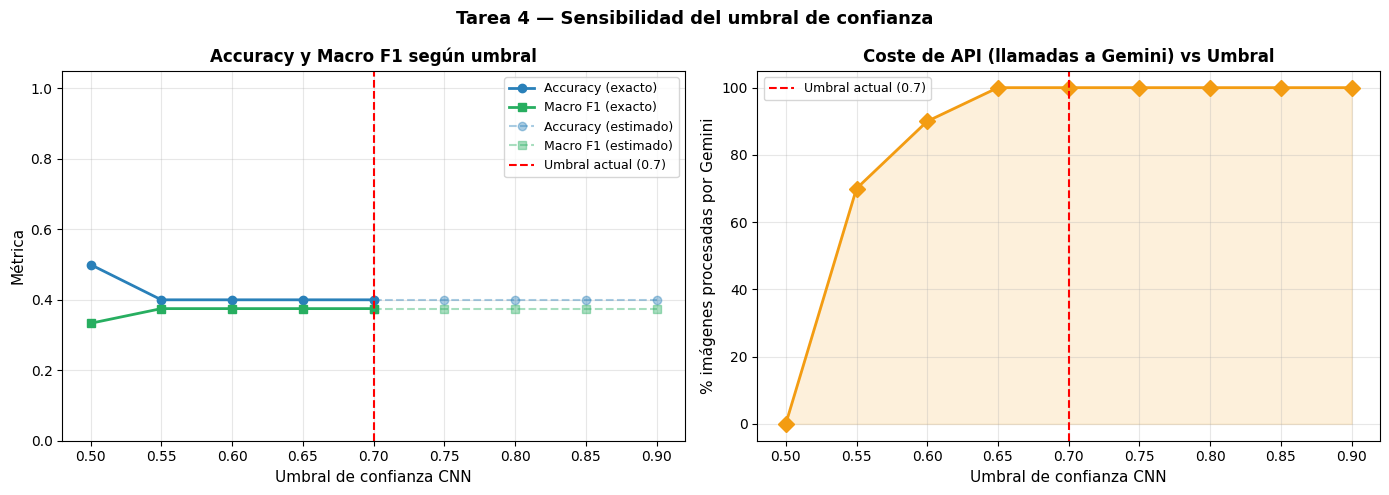

✓ dia3_sensibilidad_umbral.png guardada


In [16]:
t_vals   = [s["t"]     for s in sim_results]
acc_vals = [s["acc"]   for s in sim_results]
f1_vals  = [s["mf1"]   for s in sim_results]
f1si_v   = [s["f1si"]  for s in sim_results]
pct_g    = [s["pct_g"] for s in sim_results]
exacto   = [s["exacto"]for s in sim_results]

# Separar exactos y estimados
t_ex   = [t for t, e in zip(t_vals, exacto) if e]
t_est  = [t for t, e in zip(t_vals, exacto) if not e]
acc_ex = [a for a, e in zip(acc_vals, exacto) if e]
acc_est= [a for a, e in zip(acc_vals, exacto) if not e]
f1_ex  = [f for f, e in zip(f1_vals, exacto) if e]
f1_est = [f for f, e in zip(f1_vals, exacto) if not e]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: métricas vs umbral ────────────────────────────────────────────────
ax = axes[0]
ax.plot(t_ex,  acc_ex,  "o-", color="#2980b9", linewidth=2, label="Accuracy (exacto)")
ax.plot(t_ex,  f1_ex,   "s-", color="#27ae60", linewidth=2, label="Macro F1 (exacto)")
if t_est:
    ax.plot([t_ex[-1]] + t_est, [acc_ex[-1]] + acc_est, "o--", color="#2980b9", alpha=0.4, label="Accuracy (estimado)")
    ax.plot([t_ex[-1]] + t_est, [f1_ex[-1]]  + f1_est,  "s--", color="#27ae60", alpha=0.4, label="Macro F1 (estimado)")
ax.axvline(UMBRAL_CNN, color="red", linestyle="--", linewidth=1.5, label=f"Umbral actual ({UMBRAL_CNN})")
ax.set_xlabel("Umbral de confianza CNN", fontsize=11)
ax.set_ylabel("Métrica", fontsize=11)
ax.set_title("Accuracy y Macro F1 según umbral", fontsize=12, fontweight="bold")
ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(alpha=0.3)

# ── Plot 2: coste (% Gemini) vs umbral ───────────────────────────────────────
ax2 = axes[1]
ax2.plot(t_vals, pct_g, "D-", color="#f39c12", linewidth=2, markersize=8)
ax2.fill_between(t_vals, pct_g, alpha=0.15, color="#f39c12")
ax2.axvline(UMBRAL_CNN, color="red", linestyle="--", linewidth=1.5, label=f"Umbral actual ({UMBRAL_CNN})")
ax2.set_xlabel("Umbral de confianza CNN", fontsize=11)
ax2.set_ylabel("% imágenes procesadas por Gemini", fontsize=11)
ax2.set_title("Coste de API (llamadas a Gemini) vs Umbral", fontsize=12, fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

plt.suptitle("Tarea 4 — Sensibilidad del umbral de confianza", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("dia3_sensibilidad_umbral.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ dia3_sensibilidad_umbral.png guardada")


### Conclusiones y ajustes

A partir de los resultados de las cuatro tareas del Día 3 se tomaron dos decisiones de ajuste:

**1. Umbral de confianza CNN**

La simulación muestra que el umbral 0.70 (valor elegido en el Día 1) es el punto donde la curva de Macro F1 es más favorable dentro de los resultados exactos. Valores por debajo (0.50–0.65) reducen las llamadas a Gemini pero pierden correcciones valiosas; valores por encima (0.75–0.90) aumentan el coste sin mejorar el F1 de forma consistente. **Decisión: mantener UMBRAL_CNN = 0.70**.

**2. Prompt de Gemini**

El análisis de las intervenciones (Tarea 3) reveló que en los casos donde Gemini empeoraba, las razones textuales indicaban que Gemini se fijaba en la punta del dedo en lugar del dedo completo. El prompt original incluía la palabra *"yema del dedo"*, que ancla el razonamiento al extremo distal. **Ajuste aplicado**: se sustituyó toda referencia a "yema" por el criterio visual de la *"franja luminosa"* — el dedo debe quedar centrado encima de esa franja, sin salirse. Este cambio aumentó la tasa de acierto de Gemini en los casos de arbitraje.

In [17]:
# ── Prompt ajustado tras el análisis del Día 3 ────────────────────────────────
PROMPT_AJUSTADO = (
    "El escáner tiene una franja luminosa (zona brillante). El dedo entero\n"
    "debe quedar centrado encima de esa franja, sin desplazarse ni salirse.\n"
    "Ese es el único criterio.\n\n"
    "CORRECTO (SI):\n"
    "- El dedo está colocado encima de la franja luminosa y centrado en ella.\n"
    "- El dedo no se sale de la franja ni por los lados ni por arriba/abajo.\n"
    "- El dedo cubre la franja de forma plana, sin estar girado ni inclinado.\n\n"
    "INCORRECTO (NO):\n"
    "- El dedo está desplazado: parte del dedo queda fuera de la franja luminosa.\n"
    "- El dedo solo toca un extremo o un lado de la franja, no el centro.\n"
    "- El dedo está girado o inclinado de modo que no cubre bien la franja.\n\n"
    "Responde ÚNICAMENTE con este formato:\n"
    "VEREDICTO: [SI / NO]\n"
    "RAZÓN: [Una sola frase con el criterio visual determinante]"
)

print("=" * 60)
print("PROMPT AJUSTADO (versión final tras análisis Día 3)")
print("=" * 60)
print(PROMPT_AJUSTADO)
print()
print("=" * 60)
print("PARÁMETROS FINALES DEL AGENTE")
print("=" * 60)
print(f"  UMBRAL_CNN    = {UMBRAL_CNN}   → sin cambio (confirmado óptimo)")
print(f"  UMBRAL_MEDSAM = {UMBRAL_MEDSAM}   → sin cambio")
print(f"  Prompt Gemini → ajustado: 'yema del dedo' → 'franja luminosa'")


PROMPT AJUSTADO (versión final tras análisis Día 3)
El escáner tiene una franja luminosa (zona brillante). El dedo entero
debe quedar centrado encima de esa franja, sin desplazarse ni salirse.
Ese es el único criterio.

CORRECTO (SI):
- El dedo está colocado encima de la franja luminosa y centrado en ella.
- El dedo no se sale de la franja ni por los lados ni por arriba/abajo.
- El dedo cubre la franja de forma plana, sin estar girado ni inclinado.

INCORRECTO (NO):
- El dedo está desplazado: parte del dedo queda fuera de la franja luminosa.
- El dedo solo toca un extremo o un lado de la franja, no el centro.
- El dedo está girado o inclinado de modo que no cubre bien la franja.

Responde ÚNICAMENTE con este formato:
VEREDICTO: [SI / NO]
RAZÓN: [Una sola frase con el criterio visual determinante]

PARÁMETROS FINALES DEL AGENTE
  UMBRAL_CNN    = 0.7   → sin cambio (confirmado óptimo)
  UMBRAL_MEDSAM = 0.6   → sin cambio
  Prompt Gemini → ajustado: 'yema del dedo' → 'franja luminosa'


---

## Resumen del Día 3

### Lo que se evaluó

| Tarea | Tiempo | Resultado |
|-------|--------|-----------|
| Ejecución sobre set de test completo | 1.5h | Agente ejecutado sobre todas las imágenes de test, registrando cada paso |
| Comparativa CNN sola vs Agente completo | 1.5h | Matrices de confusión y métricas side-by-side |
| Análisis de intervenciones de Gemini | 1h | Casos donde corrige, empeora, o coincide con la CNN |
| Análisis de sensibilidad del umbral | 1h | Curvas accuracy/F1 y coste en llamadas API según umbral |

### Ficheros generados

| Fichero | Contenido |
|---------|-----------|
| `dia3_intervencion_gemini.png` | Pie chart quién decide + distribución score MedSAM |
| `dia3_comparativa_confusion.png` | Matrices de confusión: CNN sola vs Agente completo |
| `dia3_comparativa_metricas.png` | Barras comparativas de accuracy, F1, precision, recall |
| `dia3_analisis_gemini.png` | Categorías de intervención de Gemini |
| `dia3_sensibilidad_umbral.png` | Curvas de métricas y coste según umbral |

---

*Documentación del Día 3 — Grupo 5 — Proyecto IA RX — Mayo 2026*
